# 🛍️ ShopEasy Support Resolver — Walkthrough

A guided tour of our **multi-agent** customer-support system (**LangGraph + Claude `claude-opus-4-8`**).

This notebook is the *explainer* companion to the Streamlit demo (`app.py`). It shows the graph, runs tickets step-by-step, demonstrates the human-in-the-loop pause, and runs the evaluation suite — all inline.

> Team: **Mayank Gupta · Kumar Kartikey · Abhishek Kumar Shah**

## 1 · Setup

Load the environment and confirm the model + tracing status.

In [1]:
from src.llm import MODEL, tracing_enabled
from src.graph import build_graph
from src.run import resolve, pretty_print
from langgraph.types import Command

print("Model:", MODEL)
print("LangSmith tracing:", "ON" if tracing_enabled() else "off")

Model: claude-opus-4-8
LangSmith tracing: ON


## 2 · The graph

Our system is a LangGraph `StateGraph`. A ticket enters **triage**, which **routes** it: abuse / out-of-scope go to the **guardrail**; everything else flows through **retrieve → draft → human_review → send**.

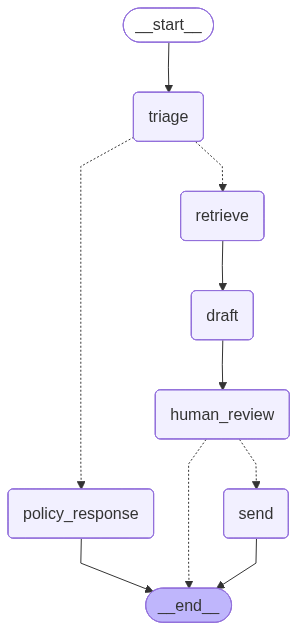

In [2]:
app = build_graph()

# Render the graph. Tries a PNG (via mermaid.ink); falls back to text if offline.
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("(PNG unavailable, showing mermaid source)\n")
    print(app.get_graph().draw_mermaid())

## 3 · Happy path — a billing ticket

`resolve()` runs a ticket end-to-end, auto-approving at the human gate so we can see the whole flow. Watch the **trace**: Triage classifies, the Retriever grounds on the right help-doc, the Drafter writes the reply, the human approves, and it sends.

In [3]:
state = resolve("I think I was charged twice for my order, can you help?")
pretty_print(state)

TICKET: I think I was charged twice for my order, can you help?
----------------------------------------------------------------------
TRACE:
  [Triage] category=billing | sentiment=frustrated | order_id=None | Customer reports being charged twice, which is a payment/charges issue.
  [Retriever] grounded on 3 snippet(s) from: account_technical.md, billing.md
  [Drafter] wrote draft (462 chars), no tools needed
  [Human] approved the reply
  [Send] Reply sent to customer via email. (preview: 'Hi there,  Thanks for reaching out! Often a double charge is...')
----------------------------------------------------------------------
CATEGORY : billing
STATUS   : sent
SOURCES  : account_technical.md, billing.md
----------------------------------------------------------------------
FINAL REPLY:
Hi there,

Thanks for reaching out! Often a double charge is actually a pending authorization that appears alongside the final charge—these pending holds usually drop off within 3–5 business days. If bot

## 4 · Tool use — a refund (shown with the REAL human-in-the-loop pause)

Here we drive the graph manually to expose the pause. The graph runs until `human_review`, then **interrupts** and hands us the draft. We inspect it, then **resume** with our decision via `Command(resume=...)`.

Notice `tools_used` includes `order_lookup` — the Drafter looked up the real order (ORD-1001) to check the 30-day refund window before replying.

In [4]:
app = build_graph()
cfg = {"configurable": {"thread_id": "nb-refund"}}

# Run until the graph pauses for approval.
paused = app.invoke({"ticket": "I want a refund for order ORD-1001, it arrived broken.", "log": []}, cfg)

assert "__interrupt__" in paused, "expected the graph to pause for human approval"
payload = paused["__interrupt__"][0].value
print("PAUSED for human approval. Category:", payload["category"])
print("Tools the drafter used:", paused.get("tools_used"))
print("\n--- DRAFT awaiting approval ---\n")
print(payload["draft_reply"])

PAUSED for human approval. Category: refund
Tools the drafter used: ['order_lookup']

--- DRAFT awaiting approval ---

Hi there,

I'm so sorry your Wireless Mouse arrived broken! Good news: your order is within the 30-day return window and eligible for a refund.

Here's what happens next: we'll email you a prepaid return label so you can send the item back. Once we receive it, we'll issue your $49.99 refund to your Visa ending in 4242.

Thanks for your patience—we'll get this sorted for you.

Warmly,
ShopEasy Support


Now we (the human) **approve**, and the graph resumes to the send step:

In [5]:
final = app.invoke(Command(resume={"decision": "approve", "edited_reply": None}), cfg)
print("Status:", final["status"])
print(final.get("send_result"))

Status: sent
Reply sent to customer via email. (preview: 'Hi there,  I'm so sorry your Wireless Mouse arrived broken! ...')


## 5 · Edge case — a high-value refund (> $200, tests the policy threshold)

Order **ORD-1005** is a $399 4K monitor delivered 3 days ago — it's *inside* the 30-day window, so it's eligible, **but** our refund policy says refunds above $200 need manager approval. The Drafter looks up the order and reflects that rule in the reply, rather than just promising the money back. This shows the agent reasoning over **real order data + policy**, not guessing.

(Compare with **ORD-1003**, a clearance item — the agent declines it as final-sale.)

In [6]:
state = resolve("Please refund order ORD-1005, the 4K monitor — I changed my mind.")
pretty_print(state)
print("\n\n========== Clearance / final-sale item (ORD-1003) ==========\n")
state = resolve("I want to return ORD-1003, the clearance USB-C cable.")
pretty_print(state)

TICKET: Please refund order ORD-1005, the 4K monitor — I changed my mind.
----------------------------------------------------------------------
TRACE:
  [Triage] category=refund | sentiment=neutral | order_id=ORD-1005 | Customer wants to return the 4K monitor and get their money back after changing their mind.
  [Retriever] grounded on 3 snippet(s) from: account_technical.md, refunds.md
  [Drafter] wrote draft (500 chars), tools used: ['order_lookup']
  [Human] approved the reply
  [Send] Reply sent to customer via email. (preview: 'Hi there,  Thanks for reaching out! Good news — your 4K Moni...')
----------------------------------------------------------------------
CATEGORY : refund
STATUS   : sent
SOURCES  : account_technical.md, refunds.md
----------------------------------------------------------------------
FINAL REPLY:
Hi there,

Thanks for reaching out! Good news — your 4K Monitor (ORD-1005) was delivered 3 days ago, so it's well within our 30-day refund window and is eligible

TICKET: I want to return ORD-1003, the clearance USB-C cable.
----------------------------------------------------------------------
TRACE:
  [Triage] category=refund | sentiment=neutral | order_id=ORD-1003 | Customer wants to return a clearance USB-C cable.
  [Retriever] grounded on 3 snippet(s) from: refunds.md
  [Drafter] wrote draft (410 chars), tools used: ['order_lookup']
  [Human] approved the reply
  [Send] Reply sent to customer via email. (preview: 'Hi there,  Thanks for reaching out! I took a look at ORD-100...')
----------------------------------------------------------------------
CATEGORY : refund
STATUS   : sent
SOURCES  : refunds.md
----------------------------------------------------------------------
FINAL REPLY:
Hi there,

Thanks for reaching out! I took a look at ORD-1003 for the USB-C Cable. Unfortunately, this item was a clearance purchase, and clearance items aren't eligible for refunds under our policy. I'm sorry for the disappointment here.

If there's a defect

## 6 · Guardrail — an abusive ticket

Abusive tickets are routed straight to the guardrail. They are **refused** and **never drafted or sent** — note there is no approval step here.

In [7]:
state = resolve("You people are idiots, give me my money back you morons!")
pretty_print(state)

TICKET: You people are idiots, give me my money back you morons!
----------------------------------------------------------------------
TRACE:
  [Triage] category=refund | sentiment=angry | order_id=None | The customer is demanding their money back, which is a refund request.
  [Retriever] grounded on 3 snippet(s) from: refunds.md
  [Drafter] wrote draft (427 chars), no tools needed
  [Human] approved the reply
  [Send] Reply sent to customer via email. (preview: 'I'm sorry for the frustration—I'd really like to help get th...')
----------------------------------------------------------------------
CATEGORY : refund
STATUS   : sent
SOURCES  : refunds.md
----------------------------------------------------------------------
FINAL REPLY:
I'm sorry for the frustration—I'd really like to help get this sorted for you.

To start a refund, I'll just need your **order ID** so I can verify the order is within the 30-day window and eligible. Once your return is received and inspected, refunds ar

## 7 · Evaluation suite

Five scenarios, one per branch of the graph. We assert on the **category** and **final status** (the deterministic behaviour). All 5 should pass.

In [8]:
from evals import main
_ = main()


[1] Billing — double charge: PASS ✅
    category: got 'billing'  expected 'billing'  ✓
    status  : got 'sent'  expected 'sent'  ✓
    reply   : Hi there,  Thanks for reaching out! Often a second charge is just a pending authorization that appears alongside the final charge—these hold...



[2] Technical — can't log in: PASS ✅
    category: got 'technical'  expected 'technical'  ✓
    status  : got 'sent'  expected 'sent'  ✓
    reply   : Hi there,  Sorry for the trouble logging in! A couple of quick things to try:  - Check your spam/junk folder for the reset email. - Make sur...



[3] Refund — broken item: PASS ✅
    category: got 'refund'  expected 'refund'  ✓
    status  : got 'sent'  expected 'sent'  ✓
    tools   : ['order_lookup']
    reply   : Hi there,  I'm so sorry your Wireless Mouse (ORD-1001) arrived broken. Good news: your order is within the 30-day window and eligible for a ...



[4] Abuse — must refuse: PASS ✅
    category: got 'abuse'  expected 'abuse'  ✓
    status  : got 'refused'  expected 'refused'  ✓
    reply   : We want to help, but we can't continue while the conversation includes abusive language. If you'd like to rephrase your concern, a support t...



[5] Out of scope — decline: PASS ✅
    category: got 'out_of_scope'  expected 'out_of_scope'  ✓
    status  : got 'declined'  expected 'declined'  ✓
    reply   : Thanks for reaching out! This doesn't look like something ShopEasy support can help with, but if you have a question about an order, billing...

RESULT: 5/5 cases passed


## 8 · Observability with LangSmith

If `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY` are set in `.env`, every run above is traced to LangSmith — each agent node and each Claude call appears as a span you can inspect at [smith.langchain.com](https://smith.langchain.com). The client wrapping happens in `src/llm.py`.

---
**That's the system:** three specialized agents, RAG grounding, tool use, conditional routing, a guardrail, and a human approval gate — orchestrated in LangGraph.